# Aula 13

# "One shot learning"

### Eduardo Lobo Lustosa Cabral


## 1. Objetivo

Apresentar o método "one shoot learning" com uma RNA siamesa aplicado a problemas de classificação multiclasse.

Apresentar as vantagens do método "one shot learning" sobre o método padrão de classificação multiclasse.

Mostrar como criar, treinar e usar uma rede neural siamesa para resover um problema de classificação multiclasse usando a função de custo tripla.


### Importação das prinicipais bibliotecas

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import random

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


## 2. Introdução

Redes neurais deep learning tornaram-se os métodos de última geração para tarefas de classificação. No entanto, uma das maiores limitações é que elas exigem muitos dados rotulados. Em muitos casos, coletar muitos dados às vezes não é viável. O método "One Shot Learning" visa resolver esse problema.

No caso de um de classificação padrão de imagens, a imagem de entrada é alimentada em uma série de camadas e, finalmente, na saída, é gerada uma distribuição de probabilidade sobre todas as classes (normalmente usando um Softmax). Por exemplo, se estamos tentando classificar uma imagem como gato ou cachorro ou cavalo ou elefante, então para cada imagem de entrada, geramos 4 probabilidades, indicando a probabilidade da imagem pertencer a cada uma das 4 classes.

Dois pontos importantes devem ser observados em um problema de classificação multiclasse:

- Primeiramente, durante o processo de treinamento, é exigido um grande número de imagens para cada uma das classes (gatos, cachorros, cavalos e elefantes).


- Em segundo lugar, se a rede for treinada apenas com as 4 classes acima, não podemos esperar testá-la em qualquer outra classe, por exemplo, “zebra”. Se quisermos que nosso modelo classifique as imagens de zebra também, primeiro precisamos obter várias imagens de zebra e, em seguida, treinar novamente o modelo.


Existem aplicações em que não temos dados suficientes para cada classe e o número total de classes é enorme, além de existirem muitas variações. Portanto, o custo da coleta de dados e do retreinamento periódico é muito alto.

Por outro lado, usando o método "one shot learning", são exigidos apenas alguns exemplos de treinamento para cada classe, ou no pior caso somente um exemplos de cada classe. Sim, você acertou, apenas um. Daí o nome One Shot. Vamos tentar entender com um exemplo prático do mundo real.


### 2.1 Problema de classificação padrão versus "one shot learning"

Suponha que desejamos construir um sistema de reconhecimento facial para uma pequena organização com apenas 10 funcionários (um pequeno número simplifica as coisas). Usando uma abordagem de classificação tradicional, podemos criar um sistema de classificação multiclasse padrão para 10 classes (10 funcionários).

Esse sistema tem alguns problemas:

- Para treinar esse sistema, primeiro exigimos muitas imagens diferentes de cada uma das 10 pessoas na organização, o que pode não ser viável. (Imagine se você estiver fazendo isso para uma organização com milhares de funcionários).

- E se uma nova pessoa entrar ou sair da organização? Você precisa ter o trabalho de coletar dados novamente e treinar novamente todo o modelo. Isso praticamente não é possível, especialmente para grandes organizações, onde o recrutamento e o desligamento acontecem quase todas as semanas.

Agora vamos entender como abordamos esse problema usando o método "one shot learning", que ajuda a resolver os dois problemas acima:

- Em vez de classificar diretamente uma imagem de entrada para uma das 10 pessoas na organização, esta rede leva uma imagem de referência extra da pessoa como entrada e produz uma pontuação de similaridade denotando as chances de que as duas imagens de entrada pertençam ao mesma pessoa. Normalmente, a probabilidade de semelhança é entre 0 e 1 usando uma função sigmóide; onde 0 denota nenhuma semelhança e 1 denota semelhança total.

- Observe que essa rede não está aprendendo a classificar uma imagem diretamente para nenhuma das classes de saída. Em vez disso, está aprendendo uma função de similaridade, que recebe duas imagens como entrada e expressa o quão semelhantes são.


Como isso resolve os dois problemas apresentados acima:

- Para treinar esta rede, não são necessárias muitas instâncias de uma classe e apenas poucas são suficientes para construir um bom modelo.

- Mas a maior vantagem é que, digamos no caso de reconhecimento facial, temos um novo funcionário que ingressou na organização. Agora, para que a rede detecte seu rosto, precisamos apenas de uma ou de algumas imagens de seu rosto, que será armazenada no banco de dados. Usando isso como imagem de referência, a rede calculará a similaridade para qualquer nova exemplo apresentado a ela.

**Para exemplificar o método "one shot learning" aplicado a um problema de classificação multiclasse vamos usar o conjunto dados de dígitos MNIST com uma função de custo tripla.**

## 3. Conjunto de dados

A célula abaixo carrega o conjunto de dados de dígitos MNIST da coleção do Keras.

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print('Dimensão dos dados de entrada de treinamento =', x_train.shape)
print('Dimensão dos dados de entrada de teste =', x_test.shape)
print('Dimensão dos dados de saída de treinamento =', y_train.shape)
print('Dimensão dos dados de saída de teste =', y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Dimensão dos dados de entrada de treinamento = (60000, 28, 28)
Dimensão dos dados de entrada de teste = (10000, 28, 28)
Dimensão dos dados de saída de treinamento = (60000,)
Dimensão dos dados de saída de teste = (10000,)


Como as imagens do conjunto de dígitos MNIST são pequenas e em tons de cinza, para simplificar esse exemplo a rede siamesa usada terá camadas densas no lugar de usar uma rede convolucional.

Dessa forma é necessário redimensionar as imagens para torná-las vetores.

In [ ]:
# Número total de pixels nas imagens
nx = x_train.shape[1]*x_train.shape[2]

# Redimensionamento das imagens
x_train_flat = np.reshape(x_train, (x_train.shape[0], nx))/255.
x_test_flat = np.reshape(x_test, (x_test.shape[0], nx))/255.

print('Dimensão dos dados de entrada de treinamento =', x_train_flat.shape)
print('Dimensão dos dados de entrada de teste =', x_test_flat.shape)

Dimensão dos dados de entrada de treinamento = (60000, 784)
Dimensão dos dados de entrada de teste = (10000, 784)


#### Gráficos de alguns exemplos

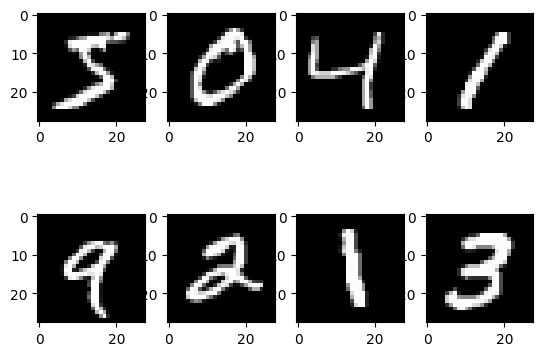

In [ ]:
fig, axs = plt.subplots(2,4)
index = 0
for i in range(2):
    for j in range(4):
        axs[i,j].imshow(x_train[index], cmap='gray', vmin=0, vmax=255)
        index += 1
plt.show()

## 4. Criação dos exemplos de triplas

Para usar a função de custo tripla, cada exemplo de treinamento deve ser composto de 3 imagens $\to$ imagem de referência, imagem positiva e imagem negativa.

A função abaixo cria os exemplos de treinamento achando triplas de imagens compostas pela imagem de referência, imagem positiva e imagem negativa.

In [ ]:
# Função para criar exemplos de treinamento
def create_batch(batch_size=256):
    x_refs, x_positives, x_negatives = [], [], []

    for i in range(0, batch_size):
        # É necessário achar um exemplo de referência, um exemplo positivo e um negativo
        random_index = random.randint(0, x_train_flat.shape[0] - 1)
        x_refs.append(x_train_flat[random_index])
        y = y_train[random_index]

        # Acha imagens de mesma classe e de classes diferentes
        indices_for_pos = np.squeeze(np.where(y_train == y))
        indices_for_neg = np.squeeze(np.where(y_train != y))

        # Escolhe aleatóriamente imagem da mesma classe (x_potive) e de classe diferente (x_negative)
        x_positives.append(x_train_flat[indices_for_pos[random.randint(0, len(indices_for_pos) - 1)]])
        x_negatives.append(x_train_flat[indices_for_neg[random.randint(0, len(indices_for_neg) - 1)]])

    return [np.stack(x_refs), np.stack(x_positives), np.stack(x_negatives)]

A função abaixo apresenta as imagens de um exemplo de treinamento (tripla).

In [ ]:
# Função para fazer gráfico da tripla
def plot_triplets(examples):
    plt.figure(figsize=(6, 2))
    for i in range(3):
        plt.subplot(1, 3, 1 + i)
        plt.imshow(np.reshape(examples[i], (28, 28)), cmap='gray')
        plt.xticks([])
        plt.yticks([])
    plt.show()

Gera um exemplo de uma tripla e mostras as imagens.

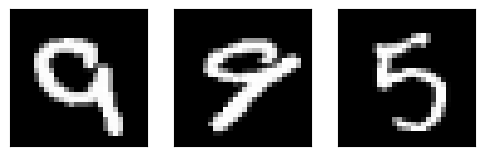

In [ ]:
example = create_batch(1)
plot_triplets(example)

## 5. Rede geradora do vetor de características

A rede para processar exemplos na forma de triplas deve possuir uma sub rede que gera os vetores de características dos três exemplos simultaneamente, para depois esses vetores serem unidos e calculadas as suas distâncias.


### 5.1 Configuração

A rede que gera o vetor de características é configurada abaixo.

In [ ]:
# Numero de características
n_carac = 64

# Rede geradora do vetor de características
carac_rna = tf.keras.models.Sequential()
carac_rna.add(tf.keras.layers.Dense(128, activation='relu', input_shape=(nx,)))
carac_rna.add(tf.keras.layers.Dense(92, activation='relu'))
carac_rna.add(tf.keras.layers.Dense(n_carac, activation='sigmoid'))

# Sumario da rede
carac_rna.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 92)             │        11,868 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         5,952 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,300 (462.11 KB)

 Trainable params: 118,300 (462.11 KB)

 Non-trainable params: 0 (0.00 B)

Observa-se que essa rede gera um vetor de características de 64 elementos.


### 5.2 Teste

Vamos testar a rede geradora do vetor de características para verificar seu funcionamento.

Observe que esse teste é realizado somente para verificar se a rede está funcionando da forma esperada e é realizado sem ela ter sido treinada.

In [ ]:
# Inclui eixo dos exemplos na imagem
example = np.expand_dims(x_train_flat[0], axis=0)

# calcula previsão da rede geradora do vetor de características
example_carac = carac_rna.predict(example)[0]

print('Dimensão do vetor de características =', example_carac.shape)
print(' ')
print('Exemplo de vetor de características:\n', example_carac)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 564ms/step
Dimensão do vetor de características = (64,)
 
Exemplo de vetor de características:
 [0.5910726  0.5831207  0.4796192  0.5461159  0.463018   0.5405552
 0.42182824 0.57314813 0.3921638  0.41036022 0.5652679  0.49004218
 0.4689925  0.52733886 0.44656312 0.49742144 0.53067684 0.5284795
 0.56603366 0.47192368 0.5224229  0.41339684 0.46827143 0.5607849
 0.5130129  0.55983657 0.5448137  0.49477774 0.48559156 0.47006375
 0.41258305 0.50271505 0.44990346 0.46217808 0.46232292 0.5339565
 0.4748787  0.5081295  0.4737698  0.44712797 0.44145015 0.4880947
 0.5090326  0.5087644  0.5495849  0.479197   0.55147254 0.484794
 0.5067908  0.5116133  0.5793458  0.48006952 0.538716   0.48352775
 0.43369412 0.45132762 0.48025906 0.5690151  0.48231584 0.47639155
 0.4313728  0.4758257  0.47698018 0.5762796 ]


## 6. Rede Siamesa

Todas as três imagens de um exemplo passam pela rede geradora de características para obter os três vetores de características:

- um para o exemplo de referência;
- um para o exemplo positivo; e
- um para o exemplo negativo.

A figura abaixo apresenta um esquema da rede siamesa usada nesse exemplo.


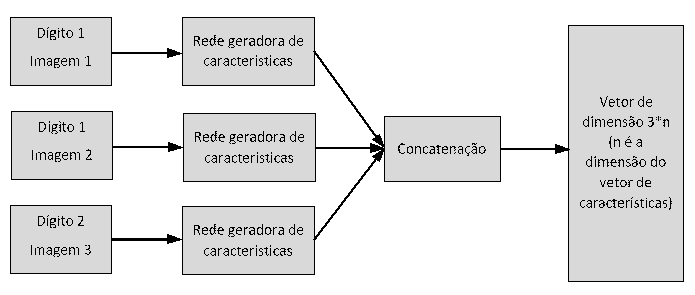

As três instâncias da RNA `carac_rna` mostradas acima não são instâncias diferentes. É a mesma instância compartilhada, ou seja, os parâmetros são compartilhados e atualizados para todos os três caminhos simultaneamente.


### 6.1 Configuração

O código abaixo cria a rede siamesa geradora de característiscas dos 3 exemplos da tripla simultaneamente.

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 64)        │    118,300 │ input_layer_1[0]… │
│ (Sequential)        │                   │            │ input_layer_2[0]… │
│                     │                   │            │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 192)       │          0 │ sequential[0][0], │
│ (Concatenate)       │                   │            │ sequential[1][0], │
│                     │                   │            │ sequential[2][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 118,300 (462.11 KB)

 Trainable params: 118,300 (462.11 KB)

 Non-trainable params: 0 (0.00 B)

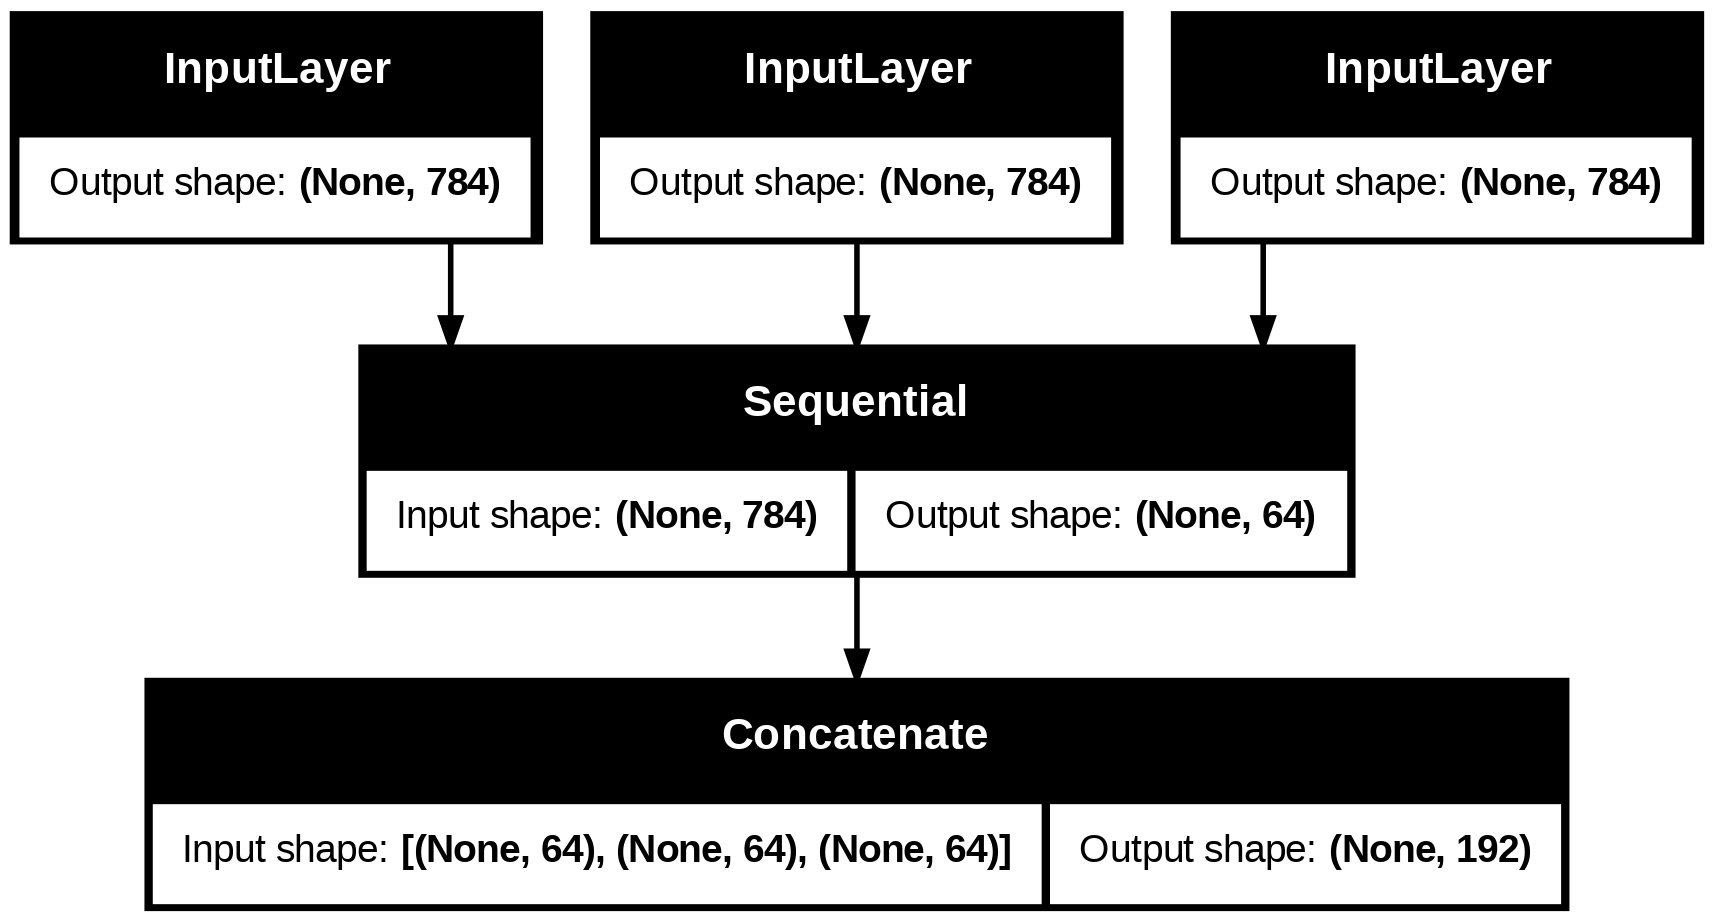

In [ ]:
# Importa função para fazer gráfico da rede
from tensorflow.keras.utils import plot_model

# Define as entradas da rede
input_reference = tf.keras.layers.Input(shape=(nx,))
input_positive = tf.keras.layers.Input(shape=(nx,))
input_negative = tf.keras.layers.Input(shape=(nx,))

# Processa imagens para gerar os vetores de características
carac_reference = carac_rna(input_reference)
carac_positive = carac_rna(input_positive)
carac_negative = carac_rna(input_negative)

# Une os vetores de características para gerar saída da rede siamesa
output = tf.keras.layers.concatenate([carac_reference, carac_positive, carac_negative], axis=1)

# cria rede siamesa
rna_siam = tf.keras.models.Model([input_reference, input_positive, input_negative], output)

# Apresenta sumario e gráfico da rede
rna_siam.summary()
plot_model(rna_siam, to_file='rna_siam.png', show_shapes=True)

### 6.2 Teste

Vamos testar a rede siamesa para verificar seu funcionamento.

Observe que esse teste é realizado somente para verificar se a rede está funcionando da forma esperada e é realizado sem ela ter sido treinada.

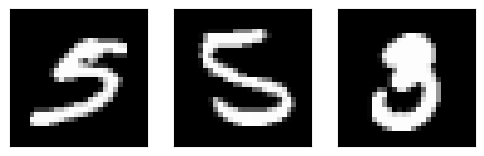

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 635ms/step
Dimensão da saida da rede siamensa = (1, 192)
 
Exemplo de saída da rede siamensa:
 [[0.59337604 0.49373144 0.5104926  0.5313705  0.5211033  0.51738536
  0.4151964  0.6001593  0.4936024  0.5663563  0.5979477  0.49391004
  0.5157391  0.42152774 0.44746292 0.48957077 0.5057985  0.5331535
  0.62804294 0.47041148 0.5390528  0.4613272  0.4533376  0.60145116
  0.5587258  0.6045196  0.5056118  0.5303873  0.46705467 0.56821233
  0.4159133  0.56896734 0.4527244  0.4979352  0.49282625 0.50859576
  0.51432335 0.5135975  0.4854683  0.47318253 0.45696953 0.46621996
  0.4812503  0.5155388  0.5569758  0.4915483  0.5236978  0.40988532
  0.44056696 0.47773048 0.49858138 0.533236   0.5576163  0.48472127
  0.45091927 0.4697245  0.5275177  0.54418194 0.46619955 0.54841626
  0.50766546 0.40628335 0.45783553 0.5276013  0.49889284 0.47363982
  0.53973114 0.4941965  0.52521443 0.51532614 0.4472071  0.53229225
  0.44064295 0.50281847 0.57492983 0.49727985 0.52679986 0.431

In [ ]:
# Cria um exemplo de triplas
example = create_batch(1)
plot_triplets(example)

# Executa a rna siamesa com esse exemplo
y_prev = rna_siam.predict(example)

print('Dimensão da saida da rede siamensa =', y_prev.shape)
print(' ')
print('Exemplo de saída da rede siamensa:\n', y_prev)

## 7. Função de custo tripla

Como visto na aula, a função de custo tripla tenta aproximar os exemplos de referência dos exemplos positivos e afastar os exemplos de referência dos exemplos negativos.

A diferença quadrada média entre os exemplos de referência e os positivos em um lote de $m$ triplas é dada por:

$$d_p = \frac{1}{m} \sum_{i=1}^{m}{||f(\mathbf{v}_{ref_i}) − f(\mathbf{v}_{pos_i})||^2}$$

A diferença quadrática média entre os exemplos de referência e os negativos em um lote de $m$ triplas é dada por:

$$d_n = \frac{1}{m} \sum_{i=1}^{m}{||f(\mathbf{v}_{ref_i}) − f(\mathbf{v}_{neg_i})||^2}$$

Para cada exemplo, queremos que:

$$d_{p_i} ≤ d_{n_i}$$

Portanto,

$$d_{p_i} − d_{n_i} ≤ 0$$

Porém, essa condição é facilmente satisfeita durante o treinamento. Assim, se adiciona uma margem $\alpha$ para que o problema não seja trivial, ou seja:

$$d_{p_i} − d_{n_i} + \alpha ≤ 0$$

Dada a condição acima, a função de custo tripla $L$ é definida como sendo:

$$L = \max{(d_p − d_n + α, 0)}$$


### 7.1 Codificação da função de custo tripla

A função abaixo define a função de custo usada para treinar exemplos formados por triplas.

In [ ]:
# Definição do parâmetro alfha
alpha = 0.2

# Função de custo tripla
def triplet_loss(y_true, y_pred):
    # Separa os 3 vetores de características
    ref, positive, negative = y_pred[:,:n_carac], y_pred[:,n_carac:2*n_carac], y_pred[:,2*n_carac:]

    # Cálculo da distancia entre os exemplos positivos
    positive_dist = tf.reduce_mean(tf.square(ref - positive), axis=1)

    # Cálculo da distância entre os exemplos negativos
    negative_dist = tf.reduce_mean(tf.square(ref - negative), axis=1)

    # Função de custo tripla
    L = tf.maximum(positive_dist - negative_dist + alpha, 0.)

    return L

- Note que o argumento `y_true` não é usado na função `triplet_loss`, mas é necessário porque uma função de custo válida para ser usada no treinamento de uma RNA no Keras exige esses os argumentos `y_true` e `y_pred`, que correspondem respectivamente à saída desejada e a saída prevista pela rede.

### 7.2 Teste

Vamos testar a função de custo para verificar seu funcionamento usando a saída calculada no item 5.

In [ ]:
# Cria vetor de saída desejada com zeros
y_true = np.zeros(y_prev.shape)

# Calcula função de custo tripla
L = triplet_loss(y_true, y_prev)

print('Valor da função de custo =', format(L))

Valor da função de custo = [0.19885169]


## 8.  Gerador de triplas

Para evitar de criar previamente o conjunto de exemplos de triplas, é usado um gerador de dados para fazer isso durante o treinamento.


### Gerador de dados

A função abaixo cria o gerador de dados que retorna um lote de exemplos de triplas. Esse gerador utiliza a função `creat_batch()` definida anteriormente. Lembre que a função `create_batch` retorna somente imagens de entrada para a rede siamesa.

Note que o gerador deve retornar também uma saída desejada para cada exemplo de treinamento. Como as saídas desejadas não são utilizadas nesse problema, mas são necessárias para poder usar o método `fit` de treinamento, então são criadas saídas desejadas "dummy" com zeros.

In [ ]:
# Gerador de triplas
def data_generator(batch_size=256):
    # Loop infinito exigido para um gerador de dados do Keras
    while True:
        # Cria lote de exemplos usando a função create_batch
        x = create_batch(batch_size)

        # Define saídas desejadas dummy para serem usadas pela função de custo
        y = np.zeros((batch_size, 3*n_carac))

        # Converte os arrays NumPy para tensores TensorFlow
        x = tf.convert_to_tensor(x)
        y = tf.convert_to_tensor(y)

        # Separa entradas
        x_ref, x_pos, x_neg = x

        # Retorna entradas e saídas dos exemplos do lote
        yield x_ref, x_pos, x_neg, y

In [ ]:
xr, xp, xn, y = next(data_generator(4))
print(len(xr), len(y))
print(xr.shape, y.shape)

4 4
(4, 784) (4, 192)


Cria dataset para permitir usar o gerador de dados.

In [ ]:
# Define tamanho do lote
batch_size = 2048

# Cria um dataset TensorFlow a partir do gerador
dataset = tf.data.Dataset.from_generator(
    data_generator,

    # Define os tipos de dados de saída
    output_types=(tf.float32, tf.float32, tf.float32, tf.float32),

    # Define dimensões dos tensores retornados
    output_shapes=(
        tf.TensorShape([None, nx]),
        tf.TensorShape([None, nx]),
        tf.TensorShape([None, nx]),
        tf.TensorShape([None, 192])
    ),
    args=(batch_size,))

# Usa função para mapear datase para combinar em uma tuple os 3 primeiros tensores de entrada
dataset = dataset.map(lambda xr, xp, xn, y: ((xr, xp, xn), y))


- Em um dataset que retorna várias variáveis tensores, deve-se definir os tipos e as dimensões da cada uma das variáveis

In [ ]:
for batch in dataset.take(1):
    x, y = batch
    print(x[0].shape, x[1].shape, x[2].shape, y.shape)

(2048, 784) (2048, 784) (2048, 784) (2048, 192)


## 9. Treinamento da rede siamesa

O treinamento da rede siamesa é realizado no Keras da mesma forma que é realizado para qualquer rede. Nesse treinamento  são usados os seguintes parâmetros:

- Tamanho do lote: 2048
- Número de épocas: 10
- Método de otimização: Adam com seus parâmetros padrão.

In [ ]:
# Definição dos parâmetros de treinamento
epochs = 10

# Calcula passos de treinamento para ter chance de usar todos os exemplos pelo menos uma vez
steps_per_epoch = int(x_train_flat.shape[0]/batch_size)

# Compilação da rede
rna_siam.compile(loss=triplet_loss, optimizer='adam')

# Treinamento
history = rna_siam.fit(dataset, steps_per_epoch=steps_per_epoch, epochs=epochs, verbose=1)

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 31s 962ms/step - loss: 0.1735
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - loss: 0.0634
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - loss: 0.0428
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - loss: 0.0359
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - loss: 0.0298
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - loss: 0.0265
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - loss: 0.0225
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - loss: 0.0202
Epoch 9/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - loss: 0.0176
Epoch 10/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - loss: 0.0158


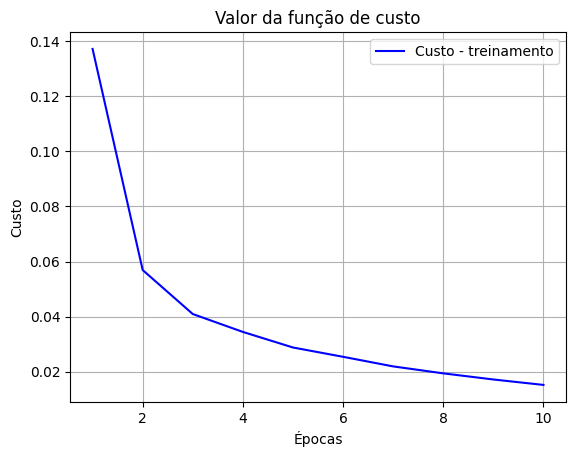

In [ ]:
# Obtém dicionário com os resultados do treinamento
results_dict = history.history

# Salva custos, métricas e epocas em vetores
custo = results_dict['loss']

# Cria vetor de épocas
epocas = range(1, len(custo) + 1)

# Gráfico dos valores de custo
plt.plot(epocas, custo, 'b', label='Custo - treinamento')
plt.title('Valor da função de custo')
plt.xlabel('Épocas')
plt.ylabel('Custo')
plt.legend()
plt.grid()
plt.show()

## 10. Avaliação e teste da rede siamesa

Para avaliar a rede siamesa vamos calcular o valor da função de custo para os dados de treinamento e depois vamos calcular algumas previsões da rede para alguns exemplos.


### 10.1 Gerador de dados de teste

Para avaliar a rede com o método `evaluate` usando os dados de teste, devemos primeiramente criar um gerador de dados de teste. Esse gerador é exatamente igual ao gerador de dados de treinamento, porém ele recebe os dados de teste.

In [ ]:
# Define gerador de dados de teste
def create_test_batch(batch_size=256):
    # Iniciliza entradas com zeros
    x_refs = np.zeros((batch_size, 784))
    x_positives = np.zeros((batch_size, 784))
    x_negatives = np.zeros((batch_size, 784))

    for i in range(0, batch_size):
        # É necessário achar um exemplo de referência, um exemplo positivo e um negativo
        random_index = random.randint(0, x_test_flat.shape[0] - 1)
        x_ref = x_test_flat[random_index]
        y = y_test[random_index]

        # Determina índices dos exemplos de mesma classe da referência e de classes diferentes
        indices_for_pos = np.squeeze(np.where(y_test == y))
        indices_for_neg = np.squeeze(np.where(y_test != y))

        # Seleciona exemplo de mesma classe e de classe diferente
        x_positive = x_test_flat[indices_for_pos[random.randint(0, len(indices_for_pos) - 1)]]
        x_negative = x_test_flat[indices_for_neg[random.randint(0, len(indices_for_neg) - 1)]]

        # Salva exemplo no tensor de dados de treinamento
        x_refs[i] = x_ref
        x_positives[i] = x_positive
        x_negatives[i] = x_negative

    # Converte os arrays NumPy para tensores TensorFlow
    x_refs = tf.convert_to_tensor(x_refs)
    x_positives = tf.convert_to_tensor(x_positives)
    x_negatives = tf.convert_to_tensor(x_negatives)

    return x_refs, x_positives, x_negatives


# Define gerador de dados de teste para ser usado com o Keras
def test_data_generator(batch_size=256):
    # Loop infinito exigido pelo Keras
    while True:
        # Cria lote de dados de entrada usando o gerador create_test_batch
        xr, xp, xn = create_test_batch(batch_size)
        y = np.zeros((batch_size, 3*n_carac))
        yield xr, xp, xn, y

Cria dataset para permitir usar o gerador de dados.

In [ ]:
# Define tamanho do lote
batch_size = 2048

# Cria um dataset TensorFlow a partir do gerador
test_dataset = tf.data.Dataset.from_generator(
    test_data_generator,

    # Define os tipos de dados de saída
    output_types=(tf.float32, tf.float32, tf.float32, tf.float32),

    # Define dimensões dos tensores retornados
    output_shapes=(
        tf.TensorShape([None, nx]),
        tf.TensorShape([None, nx]),
        tf.TensorShape([None, nx]),
        tf.TensorShape([None, 192])
    ),
    args=(batch_size,))

# Usa função para mapear datase para combinar em uma tuple os 3 primeiros tensores de entrada
test_dataset = test_dataset.map(lambda xr, xp, xn, y: ((xr, xp, xn), y))

- Em um dataset que retorna várias variáveis tensores, deve-se definir os tipos e as dimensões da cada uma das variáveis

In [ ]:
for batch in test_dataset.take(1):
    x, y = batch
    print(x[0].shape, x[1].shape, x[2].shape, y.shape)

(2048, 784) (2048, 784) (2048, 784) (2048, 192)


### 10.2 Avaliação da rede

Para avaliar a rede siamensa é usado o método `evaluate` com os dados de teste.

In [ ]:
# Calcula passos para usar todos os exemplos
steps = int(x_test_flat.shape[0]/batch_size)

# Avalia a rede siamesa com os exemplos de teste
custo = rna_siam.evaluate(test_dataset, steps=steps)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - loss: 0.0145


- Observe que o valor da função de custo para os dados de teste é particamente igual do obtido para os dados de treinamento.


### 10.3 Teste de previsão da rede

Em operação uma rede siamesa tem a função de verificar se dois exemplos de dados pertencem à mesma classe ou não. Assim, a operação da rede siamesa é diferente do seu treinamento e não usa a função de custo tripla.

O processo de uso da rede siamesa após o seu treinamento é o seguinte:

1. A rede siamesa deve receber somente dois exemplos de treinamento e calcular os vetores de características de cada um desses exemplos, $\mathbf{v}_1$ e $\mathbf{v}_2$.


2. Tendo esses vetores de características, é calculada a distância entre eles usando a distância média quadrática, ou seja:

$$d_{1,2} = ||\mathbf{v}_1 − \mathbf{v_2}||^2$$

3. A distância $d_{1,2}$ é comparada com um $limiar$ para determinar se os dois exemplos são "iguais" ou "diferentes", ou seja:

    - Se $d <= limiar$, então os dois exemplos pertencem à mesma classe

    - Se $d > limiar$, então os dois exemplos pertencem a classes diferentes


#### Prepara dados de entrada

Vamos verificar as classes do primeiros 20 exemplos de teste para podermos testar a rede siamesa

In [ ]:
for i in range(20):
    print(i, y_test[i])

In [ ]:
# Escolhe duas imagens e inclui eixo dos exemplos
ind1 = 0
ind2 = 2
x1 = np.expand_dims(x_test_flat[ind1], 0)
x2 = np.expand_dims(x_test_flat[ind2], 0)

print('Dimensão dos dados de entrada:', x1.shape, x2.shape)

# Mostra images selecionadas para teste
plt.imshow(x_test[ind1], cmap='gray')
plt.show()
plt.imshow(x_test[ind2], cmap='gray')
plt.show()
print(x1.shape, x2.shape)

#### Calcula vetores de características dos dois exemplos

In [ ]:
v1 = carac_rna(x1)
v2 = carac_rna(x2)

#### Calcula distância entre os vetores de características

A distância entre os vetores e características é calculada da mesma forma utlizada na função de custo. Pois, a rede aptrendeu a separar as classes usando essa função

In [ ]:
d12 = np.mean(np.square(v1 - v2), axis=1)
print('Distância entre os exemplos =', d12)

#### Verificação se pertencem à mesma classe

O valor do limiar utilizado para determinar se os exemplos são "iguais" ou não é o parâmetro $\alpha$ usado na função de custo tripla para ajudar a separar as classes.

Valor utilizado para $\alpha = 0.2$.

In [ ]:
if d12<=alpha:
    print("Exemplos 'iguais'")
else:
    print("Exemplos 'diferentes'")

## 11. Uso da rede siamensa para o problema de classificação de dígitos

Para usar a rede siamensa para o problema de classificação de dígitos, devemos primeiramente selecionar alguns exemplos de cada classe para serem usados como referências de cada uma das classes.

Os vetores de características desses vetores de referência são calculados previamente e guardados para serem usados posteriormente.

Ao receber uma imagem para verificação da sua classe, o vetor de característica dessa imagem é calculado e são calculadas as distâncias desse vetor para os vetores de referência de cada uma das classes. A menor distância indica a que classe é a imagem.


### 11.1 Vetores de características de referência

O primeiro passo é selecionar as imagens de referência e calcular os vetores de cada classe. Para isso vamos selecionar os primeiros 5 exemplos de cada classe do conjunto de treinamento para serem usados como referências.

In [ ]:
# Número de classe
Nc = 10

# Inicializa vetores de características de referência
v_ref = np.zeros((Nc,5,n_carac))

# Seleciona 5a primeiros exemplos de cada classe e calcula vetores de características
for i in range(Nc):
    # Identifica exemplos da classe i
    yind = np.where(y_train==i)
    z = x_train_flat[yind[0][:5]]

    # Calcula vetores de características de referência da classe i
    v_ref[i,:5,:] = carac_rna(z)

print('Dimensão dos vetores de características de referência =', v_ref.shape)

### 11.2 Determinação da classe de um exemplo

Tendo os vetores de características de referência das classe, pode-se determinar a classe de um exemplo verificando a sua distância para cada vetor de referência. A classe do exemplo corresponde à classe de referência com menor distância.

In [ ]:
# Escolhe uma imagen e inclui eixo dos exemplos
ind = 9000
x = np.expand_dims(x_test_flat[ind], 0)

# Mostra imagem selecionada
plt.imshow(x_test[ind], cmap='gray')
plt.show()

# Gera vetor de características da imagem selecionada
v = carac_rna(x)

# Calcula a distancia para os vetores de característica de cada classse
d = np.zeros((Nc,1))
for i in range(Nc):
    d[i] = 10000.0
    for j in range(5):
        dj = np.mean(np.square(v - v_ref[i,j,:]), axis=1)
        if dj < d[i]:
            d[i] = dj

print('Distância do exemplo para as classe:\n', d)

# Identifica a classe a que pertence a imagem
classe = np.argmin(d)
print('Classe do exemplo:', classe)


## 12. Conclusão

Uma rede siamesa é muito eficiente para separar classes, porém a sua utilização requer mais cálculos do que uma rede treinada para resolver um problema de múltiplas classes, mas exige um menor número de exemplos de treinamento.

Em alguns problemas onde é muito difícil obter muitos dados de treinamento, ou quando existem muitas variações dentro de cada classe, tal como, reconhecimento de faces a rede siamesa é necessária.

No lugar de uma função de custo tripla pode-se alternativamente usar um classificador binário para processar duas saídas da rede siamesa para verificar se pertence ou não à mesma classe.